CLASSIFICATION

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
# donclassif.txt : plus petit fichier pour test 
don = pd.read_csv("donclassif2.txt", header=0, sep=";")
don.head()
print(don.shape)
print(don.describe)

(70000, 2)
<bound method NDFrame.describe of              V1        V2
0      5.971089 -0.027773
1      6.035601  0.037879
2      5.968887 -0.027694
3      5.953036 -0.042402
4      6.034341  0.040049
...         ...       ...
69995 -0.566215  4.344230
69996  1.934682  5.194582
69997 -0.167337  5.744387
69998  1.216668  5.184842
69999  0.113974  5.575859

[70000 rows x 2 columns]>


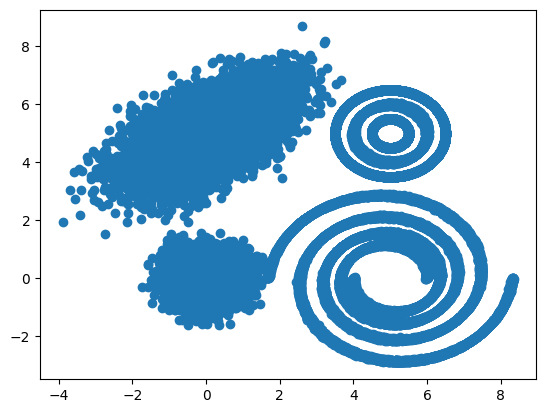

In [4]:
plt.plot(don["V1"],don["V2"],'o')
plt.show()

In [5]:
from sklearn.cluster import KMeans
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

2    17336
5    14414
3    10259
4     9882
1     9213
0     8896
Name: count, dtype: int64

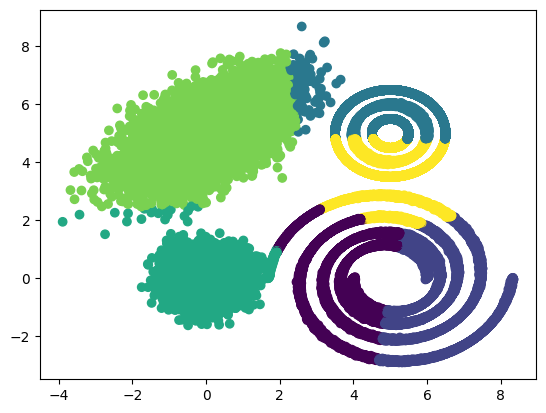

In [6]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

5    15595
4    15088
1    10755
3     9857
0     9627
2     9078
Name: count, dtype: int64


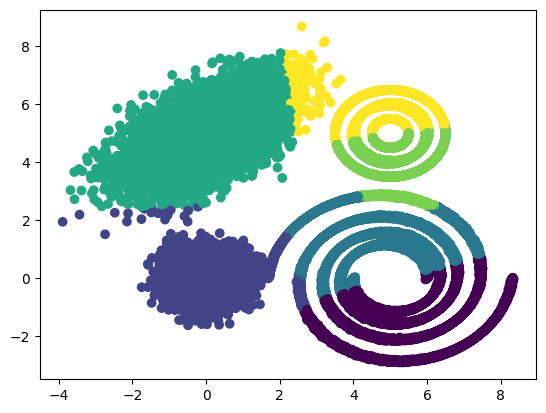

In [7]:
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
print(pd.Series(tmp.labels_).value_counts())
plt.show()

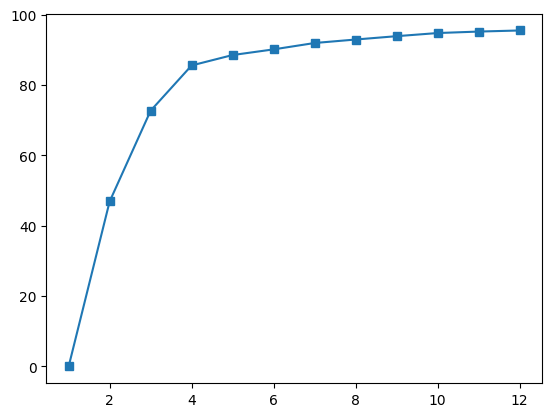

In [8]:
rapport = np.zeros(12)
inertietot = KMeans(n_clusters=1, n_init=10).fit(don)
inertietot = inertietot.inertia_
### car je ne sais pas retrouver l'inertie totale
for ii in range(1, 13):
    toto = KMeans(n_clusters=ii, n_init=10,init='random').fit(don)
    rapport[ii-1] = 100-round(toto.inertia_ / inertietot * 100, 2)
### je fais 100 moins pour avoir l'évolution croissante qui est à mon avis plus facile àlire
plt.plot(range(1, 13), rapport, marker='s')
plt.show()

je choisis 4 groupes

In [9]:
tmp = KMeans(n_clusters=4, n_init=100,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

0    31033
2    17774
3    11284
1     9909
Name: count, dtype: int64

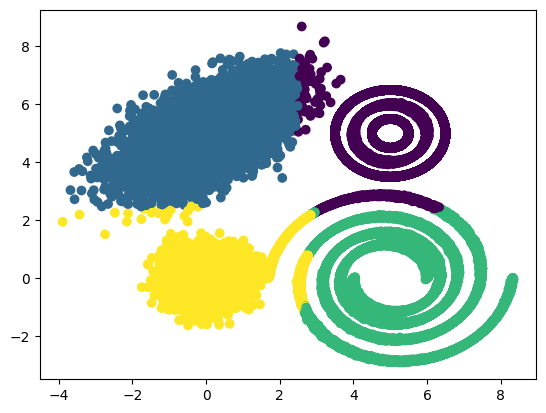

In [10]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

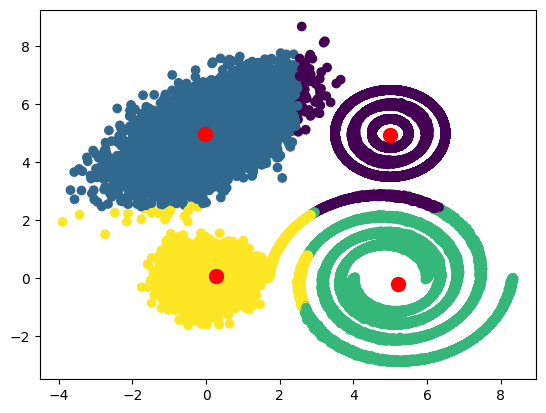

In [11]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.scatter(tmp.cluster_centers_[:,0],tmp.cluster_centers_[:,1], color="red", s=100)
plt.show()